In [2]:
!pip install -q --force-reinstall --no-deps git+https://github.com/RayenSansa03/aeroguard.git

from google.colab import drive
drive.mount("/content/drive")

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from aeroguard.decoupage import decouper_par_moteur, verifier_sans_fuite

DOSSIER = "/content/drive/MyDrive/aeroguard"
feat_dev = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev_features.parquet")
feat_test = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_test_features.parquet")
colonnes = [c for c in feat_dev.columns if c.count("_") == 2]      # les 126 features
print(feat_dev.shape, feat_test.shape, len(colonnes), "features")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(553, 132) (341, 132) 126 features


In [3]:
rng = np.random.default_rng(42)
moteurs_dev = sorted(feat_dev["unit"].unique())
moteurs_val = sorted(rng.choice(moteurs_dev, size=2, replace=False).tolist())
print("Moteurs de validation :", moteurs_val)

train, val, _ = decouper_par_moteur(feat_dev, moteurs_val=moteurs_val)
test = feat_test

verifier_sans_fuite(train, val, test)
for nom, g in [("train", train), ("val", val), ("test", test)]:
    print(f"{nom:5s} : {len(g):3d} vols | moteurs {sorted(g['unit'].unique())}")

Moteurs de validation : [1, 5]
train : 364 vols | moteurs [np.int32(2), np.int32(3), np.int32(4), np.int32(6)]
val   : 189 vols | moteurs [np.int32(1), np.int32(5)]
test  : 341 vols | moteurs [np.int32(7), np.int32(8), np.int32(9), np.int32(10)]


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def erreur_copieur(entrainement, evaluation):
    """Le copieur recopie le RUL du vol le plus ressemblant. Retourne l'erreur moyenne (en vols)."""
    copieur = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=1))
    copieur.fit(entrainement[colonnes], entrainement["RUL"])
    prediction = copieur.predict(evaluation[colonnes])
    return np.abs(prediction - evaluation["RUL"]).mean()

# ❌ Mauvais : on mélange les vols au hasard
train_hasard, val_hasard = train_test_split(feat_dev, test_size=len(val), random_state=42)
err_hasard = erreur_copieur(train_hasard, val_hasard)

# ✅ Bon : par moteur
err_moteur = erreur_copieur(train, val)

print(f"Découpage AU HASARD : erreur moyenne = {err_hasard:5.1f} vols")
print(f"Découpage PAR MOTEUR : erreur moyenne = {err_moteur:5.1f} vols")

Découpage AU HASARD : erreur moyenne =  12.4 vols
Découpage PAR MOTEUR : erreur moyenne =  12.4 vols


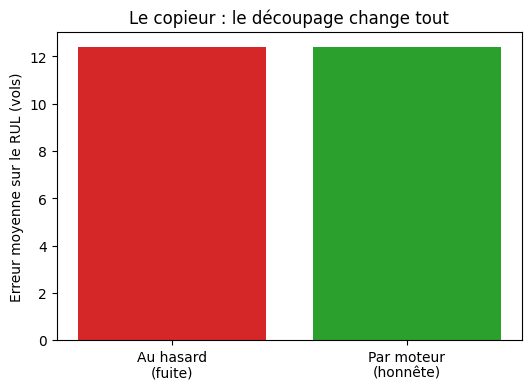

In [5]:
plt.figure(figsize=(6, 4))
plt.bar(["Au hasard\n(fuite)", "Par moteur\n(honnête)"], [err_hasard, err_moteur],
        color=["tab:red", "tab:green"])
plt.ylabel("Erreur moyenne sur le RUL (vols)")
plt.title("Le copieur : le découpage change tout")
plt.savefig(f"{DOSSIER}/results/figures/18_fuite_copieur.png", dpi=120)
plt.show()

In [6]:
decoupage = {"train": sorted(train["unit"].unique().tolist()),
             "val": moteurs_val,
             "test": sorted(test["unit"].unique().tolist())}
with open(f"{DOSSIER}/data/processed/decoupage_ds01.json", "w") as f:
    json.dump(decoupage, f, indent=2)
print(decoupage)

{'train': [2, 3, 4, 6], 'val': [1, 5], 'test': [7, 8, 9, 10]}
